In this exercise, we will generate simulated data, and will then use
this data to perform forward and backward stepwise selection.

(a) Create a random number generator and use its normal() method
to generate a predictor X of length n = 100, as well as a noise
vector " of length n = 100.

In [16]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

np.random.seed(0)
n = 100
X = np.random.normal(0, 1, size=n)
eps = np.random.normal(0, 1, size=n)

data = pd.DataFrame({
    f"X{i}": X**i for i in range(1, 11)
})

(b) Generate a response vector Y of length n = 100 according to
the model
Y = β0 + β1X + β2X2 + β3X3 + ",
where β0, β1, β2, and β3 are constants of your choice.

In [17]:
beta0 = 1.0
beta1 = 2.0
beta2 = 3.0
beta3 = 4.0

Y = beta0 + beta1 * X + beta2 * X**2 + beta3 * X**3 + eps

(c) Use forward stepwise selection in order to select a model containing the predictors X, X2,...,X10. What is the model obtained
according to Cp? Report the coefficients of the model obtained.

In [18]:
def fit_ols(y, X):
    X_const = sm.add_constant(X)
    model = sm.OLS(y, X_const).fit()
    return model

def calc_cp(model, sigma2_full, n):
    k = model.df_model + 1
    rss = np.sum(model.resid**2)
    cp = rss / sigma2_full - (n - 2 * k)
    return cp

def forward_stepwise_cp(y, X_all):
    n = len(y)
    predictors = []
    remaining = list(X_all.columns)

    full_model = fit_ols(y, X_all)
    sigma2_full = np.sum(full_model.resid**2) / full_model.df_resid

    current_model = None
    current_cp = None

    while len(remaining) > 0:
        candidate_results = []
        for col in remaining:
            cols_to_fit = predictors + [col]
            model = fit_ols(y, X_all[cols_to_fit])
            cp = calc_cp(model, sigma2_full, n)
            candidate_results.append((cp, col, model))

        candidate_results.sort(key=lambda x: x[0])
        best_cp, best_col, best_model = candidate_results[0]

        if (current_cp is None) or (best_cp < current_cp):
            predictors.append(best_col)
            remaining.remove(best_col)
            current_model = best_model
            current_cp = best_cp
        else:
            break

    return predictors, current_model, current_cp

def backward_stepwise_cp(y, X_all):
    n = len(y)
    predictors = list(X_all.columns)

    full_model = fit_ols(y, X_all)
    sigma2_full = np.sum(full_model.resid**2) / full_model.df_resid

    current_model = full_model
    current_cp = calc_cp(current_model, sigma2_full, n)

    while len(predictors) > 1:
        candidate_results = []
        for col in predictors:
            subset = [c for c in predictors if c != col]
            model = fit_ols(y, X_all[subset])
            cp = calc_cp(model, sigma2_full, n)
            candidate_results.append((cp, col, subset, model))

        candidate_results.sort(key=lambda x: x[0])
        best_cp, removed_col, best_subset, best_model = candidate_results[0]

        if best_cp < current_cp:
            predictors = best_subset
            current_model = best_model
            current_cp = best_cp
        else:
            break

    return predictors, current_model, current_cp

fwd_predictors, fwd_model, fwd_cp = forward_stepwise_cp(Y, data)

print("=== (c) Forward stepwise (criterion = Cp) ===")
print("Selected variables：", fwd_predictors)
print("Cp value：", fwd_cp)
print(fwd_model.summary())

=== (c) Forward stepwise (criterion = Cp) ===
Selected variables： ['X3', 'X2', 'X1', 'X5']
Cp value： 4.438594292476566
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     5557.
Date:                Thu, 20 Nov 2025   Prob (F-statistic):          1.15e-111
Time:                        12:01:55   Log-Likelihood:                -142.54
No. Observations:                 100   AIC:                             295.1
Df Residuals:                      95   BIC:                             308.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------

(d) Repeat (c), using backwards stepwise selection. How does your
answer compare to the results in (c)?

In [19]:
bwd_predictors, bwd_model, bwd_cp = backward_stepwise_cp(Y, data)

print("\n=== (d) Backward stepwise (criterion = Cp) ===")
print("Selected variables：", bwd_predictors)
print("Cp value：", bwd_cp)
print(bwd_model.summary())


=== (d) Backward stepwise (criterion = Cp) ===
Selected variables： ['X1', 'X2', 'X3', 'X4', 'X7', 'X9']
Cp value： 5.185414813850741
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     3756.
Date:                Thu, 20 Nov 2025   Prob (F-statistic):          1.25e-108
Time:                        12:01:55   Log-Likelihood:                -140.78
No. Observations:                 100   AIC:                             295.6
Df Residuals:                      93   BIC:                             313.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975

(e) Now fit a lasso model to the simulated data, again using X, X2,
...,X10 as predictors. Use cross-validation to select the optimal
value of λ. Create plots of the cross-validation error as a function
of λ. Report the resulting coefficient estimates, and discuss the
results obtained.


=== (e) Lasso CV result ===
Best alpha(λ)： 0.04230947194937912
The corresponding coefficients (corresponding to X1~X10)：
X1: 2.1269
X2: 3.5010
X3: 12.7339
X4: 0.2964
X5: 0.0000
X6: 0.0000
X7: -0.0000
X8: 0.0000
X9: -0.0000
X10: 0.0000


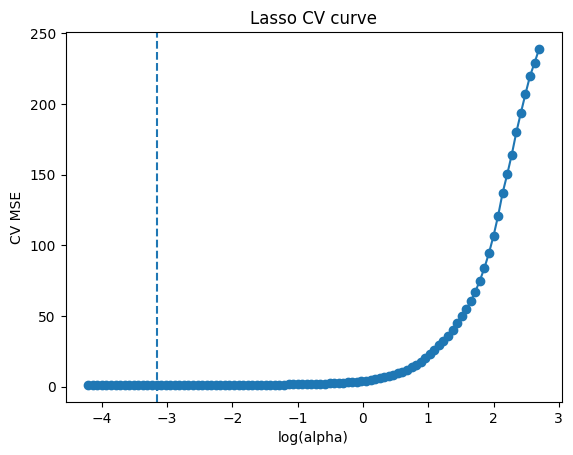

In [20]:
lasso = make_pipeline(
    StandardScaler(),
    LassoCV(cv=10, random_state=0)
)
lasso.fit(data.values, Y)

lasso_cv = lasso.named_steps["lassocv"]

print("\n=== (e) Lasso CV result ===")
print("Best alpha(λ)：", lasso_cv.alpha_)
print("The corresponding coefficients (corresponding to X1~X10)：")
for name, coef in zip(data.columns, lasso_cv.coef_):
    print(f"{name}: {coef:.4f}")

plt.figure()
mean_mse = np.mean(lasso_cv.mse_path_, axis=1)
plt.plot(np.log(lasso_cv.alphas_), mean_mse, marker="o")
plt.axvline(np.log(lasso_cv.alpha_), linestyle="--")
plt.xlabel("log(alpha)")
plt.ylabel("CV MSE")
plt.title("Lasso CV curve")
plt.show()

(f) Now generate a response vector Y according to the model
Y = β0 + β7X7 + ",
and perform forward stepwise selection and the lasso. Discuss
the results obtained.

In [21]:
beta0_f = 1.0
beta7_f = 10.0

Y2 = beta0_f + beta7_f * X**7 + eps

fwd_predictors2, fwd_model2, fwd_cp2 = forward_stepwise_cp(Y2, data)
print("\n=== (f) Forward stepwise (new Y with X^7) ===")
print("選到的變數：", fwd_predictors2)
print("Cp 值：", fwd_cp2)
print(fwd_model2.summary())

lasso2 = make_pipeline(
    StandardScaler(),
    LassoCV(cv=10, random_state=0)
)
lasso2.fit(data.values, Y2)
lasso2_cv = lasso2.named_steps["lassocv"]

print("\n=== (f) Lasso CV (new Y with X^7) ===")
print("最佳 alpha(λ)：", lasso2_cv.alpha_)
print("對應的係數（對應 X1~X10）：")
for name, coef in zip(data.columns, lasso2_cv.coef_):
    print(f"{name}: {coef:.4f}")



=== (f) Forward stepwise (new Y with X^7) ===
選到的變數： ['X7', 'X3']
Cp 值： 2.9978166415611156
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.405e+07
Date:                Thu, 20 Nov 2025   Prob (F-statistic):          2.83e-284
Time:                        12:01:55   Log-Likelihood:                -143.87
No. Observations:                 100   AIC:                             293.7
Df Residuals:                      97   BIC:                             301.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------